--- Please click the button below to upload your 'test.csv' file ---


Saving test.csv.csv to test.csv (1).csv

--- FIRST 5 ROWS ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

--- STATISTICAL SUMMARY ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200



--- MISSING VALUES BEFORE CLEANING ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

--- MISSING VALUES AFTER CLEANING ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


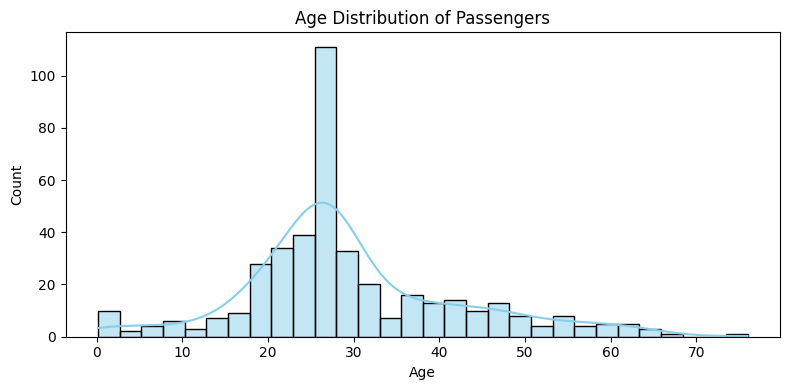

/tmp/ipykernel_695/2905614988.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df, palette='Set2')


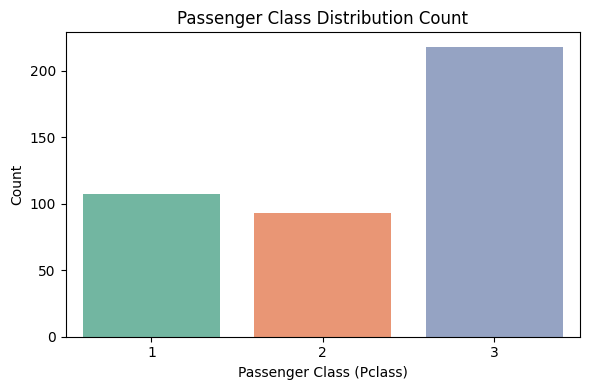

/tmp/ipykernel_695/2905614988.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, palette='pastel')


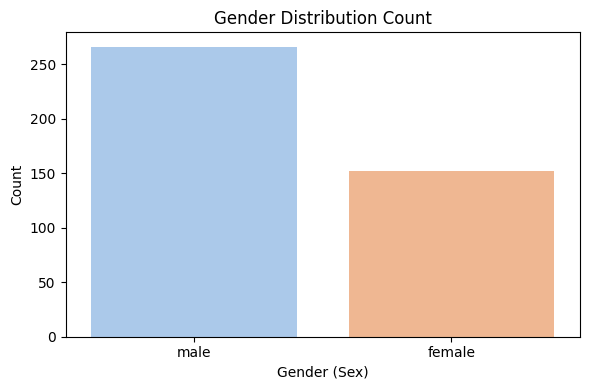

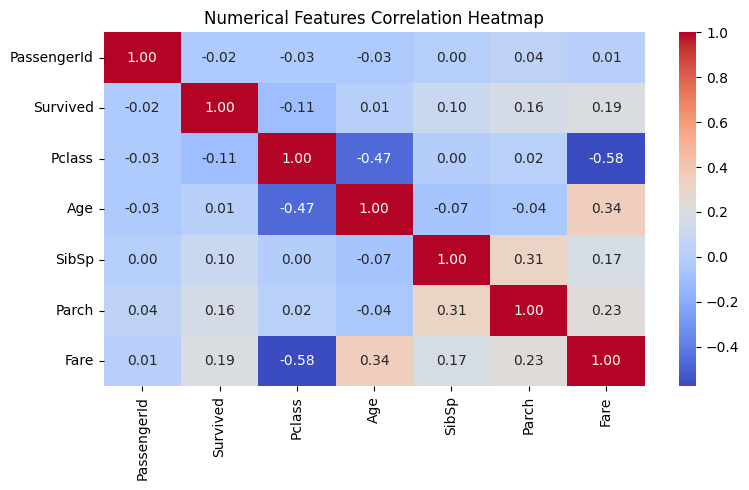


Data preprocessing and exploratory visualization completed successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ===============================================================
# STEP 1: UPLOAD AND LOAD THE DATASET
# ===============================================================
print("--- Please click the button below to upload your 'test.csv' file ---")
uploaded = files.upload()

# Load the uploaded file directly from session memory
df = pd.read_csv("test.csv.csv")


# 1. Display first 5 rows
print("\n--- FIRST 5 ROWS ---")
display(df.head())

# 2. Display basic information structure
print("\n--- DATASET INFORMATION ---")
df.info()

# 3. Display statistical matrix summary
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

# 4. Check missing values before processing
print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())


# ===============================================================
# STEP 2: DATA CLEANING & IMPUTATION
# ===============================================================
# Handle blank data cells gracefully without chaining assignment errors
df["Age"] = df["Age"].fillna(df["Age"].median())

if "Fare" in df.columns:
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove high-missing columns like Cabin if it exists
if "Cabin" in df.columns:
    df.drop("Cabin", axis=1, inplace=True)

print("\n--- MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())


# ===============================================================
# STEP 3: DATA VISUALIZATION AND CHARTS
# ===============================================================
# Chart 1: Age Distribution Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Chart 2: Passenger Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", data=df, palette='Set2')
plt.title("Passenger Class Distribution Count")
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Chart 3: Gender Counts
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", data=df, palette='pastel')
plt.title("Gender Distribution Count")
plt.xlabel("Gender (Sex)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Chart 4: Correlation Heatmap matrix
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Features Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\nData preprocessing and exploratory visualization completed successfully!")
